In [1]:
import os
import sys
import yaml

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

In [2]:
results_base_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data"
run_settings = os.listdir(results_base_dir)
run_settings = [run for run in run_settings if run.split("-")[1] == "pure_populations"]

run_paths = [
    os.path.join(results_base_dir, run)
    for run in run_settings
]
run_paths

['/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data/penalized_oxy_days-pure_populations-reciprocal',
 '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data/penalized_all_axes-pure_populations-constant',
 '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data/unconstrained-pure_populations-reciprocal',
 '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data/unconstrained-pure_populations-constant',
 '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data/penalized_all_axes-pure_populations-reciprocal',
 '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/raw_data/penalized_oxy_days-pure_populations-constant']

In [3]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"

with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
print(protocol_cols)

['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']


In [4]:
from pathlib import Path 
import anndata as ad

real_protocol_path = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous")
real_protocol_adata = ad.read_h5ad(real_protocol_path / "unique_concentrations_adata.h5ad")


ubound = (np.exp(real_protocol_adata.X) - 1).max(0)
lbound = (np.exp(real_protocol_adata.X) - 1).min(0)

bounds = {}
for i, param in enumerate(np.array(real_protocol_adata.var.index)):
    if param in protocol_cols:
        bounds[param] = (lbound[i], ubound[i])

In [5]:
protocol_cols = [
    "gm-csf_[ng_ml]",
    "tpo_[ng_ml]",
    "sr1_[nm]",
    "um171_[nm]",
    "um729_[µm]",
    "scf_[ng_ml]",
    "butyzamide_[nm]",
    "retinoic_acid_[µm]",
    "ldl_[ng_ml]",
    "il3_[ng_ml]",
    "o2_[%]",
    "days_of_culture"
]

cts = [
    "CD14-Mono",
    "CD49c-Myeloid",
    "CyclingProgenitor*",
    "DCs-CD14",
    "EarlyGMP",
    "Early_Pro-B",
    "EosBasoMastPre",
    "EosBasoMastPre_2",
    "EryPro",
    "GMP-Cycle",
    "GMP-Neutro",
    "GMP-Neutro/CD16-Mono",
    "HSCs",
    "MEP",
    "MLP",
    "MPP",
    "MgkPro",
    "Pro-B",
    "pDCs/cDCs",
]
ct_props = [f"{ct}_prop" for ct in cts]
ct_props_std = [f"{ct}_std" for ct in ct_props]

score_props = [
    "exploitation_score",
    "exploration_score",
    "weighted_uncertainty_score"
]

constraints_config = [
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "cfg:constraints:use_exponential_penalty",
]

columns_of_interest = protocol_cols + \
    ct_props + ct_props_std + score_props + \
    constraints_config

In [6]:
celltype_fraction = {
    "MgkPro": 0.2,
    "HSCs": 0.2,
    "EryPro": 0.2,
    "GMP-Neutro/CD16-Mono": 0.2,
    "CyclingProgenitor*": 0.30,
    "EosBasoMastPre": 0.30,
    "Early_Pro-B": 0.20,
    "Pro-B": 0.10,
    "CD14-Mono": 0.24,
    "DCs-CD14": 0.20
}


In [7]:
def manual_filtering(df_dict, bounds, columns_to_keep, celltype_fraction, margin_frac_prop, margin_frac_bounds, protocol_cols):
    # Filtered data frame 
    df_dict_filtered = {}
    # Iterate over cell types 
    for cell_type in df_dict: 
        # Cell type reversion 
        cell_type_revert_safe_string = cell_type.replace(":", "/")
        df_ct = df_dict[cell_type].copy()
        df_ct = df_ct.sort_values(by=f"{cell_type_revert_safe_string}_prop", ascending=False)
        df_ct = df_ct[df_ct[f"{cell_type_revert_safe_string}_prop"] > (celltype_fraction[cell_type_revert_safe_string] - celltype_fraction[cell_type_revert_safe_string] * margin_frac_prop)]
        df_ct = df_ct.loc[:, columns_to_keep]

        # Oxygen and days 
        df_ct = df_ct[df_ct["o2_[%]"]>7]
        df_ct = df_ct[df_ct["o2_[%]"]<23]
        df_ct = df_ct[df_ct["days_of_culture"]>12]
        df_ct = df_ct[df_ct["days_of_culture"]<20]

        # Bounds 
        for param in protocol_cols:
            df_ct = df_ct[df_ct[param]>=(bounds[param][0] - bounds[param][0] * margin_frac_bounds)]
            df_ct = df_ct[df_ct[param]<=(bounds[param][1] + bounds[param][1] * margin_frac_bounds)]
        
        df_dict_filtered[cell_type] = df_ct
    return df_dict_filtered

In [8]:
dfs_list = []

for run_dir in run_paths:
    run_settings = run_dir.split("/")[-1]
    opt_type, target_type, scheduler_type = run_settings.split("-")
    target_cts = os.listdir(run_dir)
    target_ct_dirs = [
        os.path.join(run_dir, ct) for ct in target_cts
    ]
    for ct_dir in target_ct_dirs:
        ct_name = ct_dir.split("/")[-1]
        ct_runs = os.listdir(ct_dir)
        ct_runs_dirs = [
            os.path.join(ct_dir, run) for run in ct_runs
        ]
        for run_path in ct_runs_dirs:
            run_id = run_path.split("/")[-1]
            df_path = os.path.join(run_path, "uncertainty_annotation/candidates_with_uncertainties.csv")
            if not os.path.isfile(df_path):
                print(f"Skipping {run_settings=}, {ct_name=}, {run_id=}")
                continue
            df = pd.read_csv(
                df_path,
                index_col="sample_id",
            ).drop(columns=['Unnamed: 0'])
            df.index.name = "sample_id"
            df["opt_type"] = opt_type
            df["target_type"] = target_type   
            df["scheduler_type"] = scheduler_type
            df['cell_type'] = ct_name
            df['run_id'] = run_id
            dfs_list.append(df)

if dfs_list:
    master_df = pd.concat(dfs_list)
    master_df = master_df.set_index(
        ['opt_type', 'target_type', 'scheduler_type', 'cell_type', 'run_id'], 
        append=True
    )
    master_df = master_df.reorder_levels(['opt_type', 'target_type', 'scheduler_type', 'cell_type', 'run_id', 'sample_id'])

In [9]:
ct_df_dict = {}
for target_ct in master_df.index.get_level_values("cell_type").unique():
    ct_df_dict[target_ct] = master_df.loc[master_df.index.get_level_values("cell_type") == target_ct]

In [21]:
filtered_df = manual_filtering(
    ct_df_dict,
    bounds,
    columns_of_interest, 
    celltype_fraction,
    margin_frac_prop=0.2, 
    margin_frac_bounds=0.1, 
    protocol_cols=protocol_cols
)
master_df_filtered = pd.concat(
    filtered_df.values(), axis=0
)
master_df_filtered["target_ct"] = master_df_filtered.index.get_level_values("cell_type")


In [32]:
metadata_csv_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/table_metadata_theis_unmix8.xlsx"
metadata_df = pd.read_excel(metadata_csv_path)
metadata_df.columns = [c.replace("/", "_") for c in metadata_df.columns]
metadata_df = metadata_df.loc[
    metadata_df["experiment_id"] == "LPHO012",
    protocol_cols + ["experiment_number", "experiment_id"]
]
exp210 = metadata_df[metadata_df["experiment_number"] == 210]
for col in protocol_cols:
    exp210[col] = exp210[col].astype(float)
ex210_log1p = np.log1p(exp210[protocol_cols].values)
ex210_log1p

/tmp/ipykernel_849198/775454857.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp210[col] = exp210[col].astype(float)
/tmp/ipykernel_849198/775454857.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp210[col] = exp210[col].astype(float)
/tmp/ipykernel_849198/775454857.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

array([[0.        , 0.        , 0.        , 4.26267988, 0.        ,
        0.        , 4.61512052, 0.        , 0.        , 0.        ,
        3.04452244, 2.7080502 ]])

In [34]:
tgt_ct = "MgkPro"
tgt_ct_df = filtered_df[tgt_ct].sort_values(f"{tgt_ct}_prop", axis=0, ascending=False)
for col in protocol_cols:
    tgt_ct_df[col] = tgt_ct_df[col].astype(float)
opt_prot_log1p = np.log1p(tgt_ct_df[protocol_cols].values)
opt_prot_log1p

array([[0.        , 0.8571997 , 0.90403008, ..., 3.07147118, 2.35953766,
        2.95584916],
       [0.        , 1.27175723, 1.22133068, ..., 3.08125879, 2.34710874,
        2.94832972],
       [0.        , 1.26345387, 1.2063768 , ..., 3.0644555 , 2.37138132,
        2.94582749],
       ...,
       [0.        , 0.06710045, 2.11554578, ..., 2.57986828, 2.93939258,
        2.98267079],
       [0.        , 0.07183158, 1.82274126, ..., 2.60890632, 2.97826663,
        2.99051398],
       [0.        , 0.01928774, 1.22158716, ..., 2.57385611, 2.48273421,
        3.01403098]], shape=(1104, 12))

<Axes: ylabel='Density'>

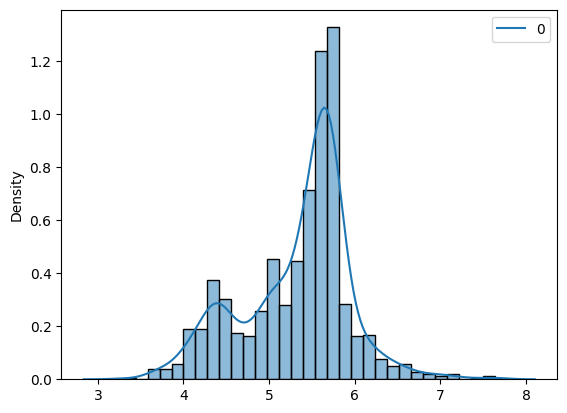

In [40]:
from scipy.spatial.distance import cdist
D = cdist(opt_prot_log1p,ex210_log1p) 

sns.histplot(D, stat="density")
sns.kdeplot(D)

In [44]:
min_idx = D.argmin(0)
tgt_ct_df.iloc[min_idx][protocol_cols]

,,,,,,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
opt_type,target_type,scheduler_type,cell_type,run_id,sample_id,,,,,,,,,,,,
penalized_oxy_days,pure_populations,constant,MgkPro,2026-02-24_17-54-18_bb9992a0,MgkPro:2026-02-24_17-54-18_bb9992a0:89,2.59332,0.092079,1.058537,50.50305,0.0,0.0,23.486666,0.0,0.0,11.829242,17.98913,19.44427


In [45]:
exp210

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,experiment_number,experiment_id
267,0.0,0.0,0.0,70.0,0.0,0.0,100.0,0.0,0.0,0.0,20.0,14.0,210,LPHO012


In [46]:
tgt_ct_df.iloc[min_idx].columns

Index(['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'o2_[%]', 'days_of_culture', 'CD14-Mono_prop',
       'CD49c-Myeloid_prop', 'CyclingProgenitor*_prop', 'DCs-CD14_prop',
       'EarlyGMP_prop', 'Early_Pro-B_prop', 'EosBasoMastPre_prop',
       'EosBasoMastPre_2_prop', 'EryPro_prop', 'GMP-Cycle_prop',
       'GMP-Neutro_prop', 'GMP-Neutro/CD16-Mono_prop', 'HSCs_prop', 'MEP_prop',
       'MLP_prop', 'MPP_prop', 'MgkPro_prop', 'Pro-B_prop', 'pDCs/cDCs_prop',
       'CD14-Mono_prop_std', 'CD49c-Myeloid_prop_std',
       'CyclingProgenitor*_prop_std', 'DCs-CD14_prop_std', 'EarlyGMP_prop_std',
       'Early_Pro-B_prop_std', 'EosBasoMastPre_prop_std',
       'EosBasoMastPre_2_prop_std', 'EryPro_prop_std', 'GMP-Cycle_prop_std',
       'GMP-Neutro_prop_std', 'GMP-Neutro/CD16-Mono_prop_std', 'HSCs_prop_std',
       'MEP_prop_std', 'MLP_prop_std', 'MPP_prop_std', 'MgkP

In [48]:
tgt_ct_df.iloc[min_idx]["MgkPro_prop"]

opt_type            target_type       scheduler_type  cell_type  run_id                        sample_id                             
penalized_oxy_days  pure_populations  constant        MgkPro     2026-02-24_17-54-18_bb9992a0  MgkPro:2026-02-24_17-54-18_bb9992a0:89    0.189193
Name: MgkPro_prop, dtype: float64

In [47]:
tgt_ct_df.iloc[min_idx]["MgkPro_prop_std"]

opt_type            target_type       scheduler_type  cell_type  run_id                        sample_id                             
penalized_oxy_days  pure_populations  constant        MgkPro     2026-02-24_17-54-18_bb9992a0  MgkPro:2026-02-24_17-54-18_bb9992a0:89    2.678227
Name: MgkPro_prop_std, dtype: float64

In [ ]:
tgt_ct_df.iloc[min_idx]["exploitation_score"]

opt_type            target_type       scheduler_type  cell_type  run_id                        sample_id                             
penalized_oxy_days  pure_populations  constant        MgkPro     2026-02-24_17-54-18_bb9992a0  MgkPro:2026-02-24_17-54-18_bb9992a0:89    0.246532
Name: exploitation_score, dtype: float64